In [8]:
import torch
from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,
import torch.optim as optim #Optimization module
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

import torchvision
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from torchvision.ops import Conv2dNormActivation

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sn

import matplotlib.pyplot as plt
import numpy as np
import random
import time
import warnings
import os
from tqdm import tqdm

import pandas as pd
%matplotlib inline
warnings.filterwarnings("ignore")

In [9]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

#### Download and Extract the Dataset

In [14]:
!wget -q "https://www.dropbox.com/s/45jdd8padeyjq6t/10_Monkey_Species.zip?dl=1" -O "10_Monkey_Species.zip"

^C


In [16]:
!unzip -q "10_Monkey_Species.zip"

unzip:  cannot find or open 10_Monkey_Species.zip, 10_Monkey_Species.zip.zip or 10_Monkey_Species.zip.ZIP.


#### Dataset and Training Configuration Parameters

In [18]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 32
    num_epochs: int = 50
    learning_rate: float = 1e-4

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./images/module_4/"
    num_workers: int = 4 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cpu


#### Load Custom data available in Pytorch

In [21]:
train_root = os.path.join(train_config.data_root,"10_Monkey_Species", "training", "training")
val_root = os.path.join(train_config.data_root, "10_Monkey_Species", "validation", "validation")

In [23]:
df = pd.read_csv(os.path.join(train_config.data_root,"10_Monkey_Species","monkey_labels.txt"), sep=",", header=None)
df.columns = ["Label", "Latin Name", "Common Name", "Train Images", "Validation Images"]
df['Latin Name'] = df['Latin Name'].str.replace("\t", " ")
df[1:]

,Label,Latin Name,Common Name,Train Images,Validation Images
1,n0,alouatta_palliata,mantled_howler,131,26
2,n1,erythrocebus_patas,patas_monkey,139,28
3,n2,cacajao_calvus,bald_uakari,137,27
4,n3,macaca_fuscata,japanese_macaque,152,30
5,n4,cebuella_pygmea,pygmy_marmoset,131,26
6,n5,cebus_capucinus,white_headed_capuchin,141,28
7,n6,mico_argentatus,silvery_marmoset,132,26
8,n7,saimiri_sciureus,common_squirrel_monkey,142,28
9,n8,aotus_nigriceps,black_headed_night_monkey,133,27
10,n9,trachypithecus_johnii,nilgiri_langur,132,26


#### Data Preprocessing

In [24]:
mean = [0.4368, 0.4336, 0.3294]  #mean and std of this Monkey Species dataset
std = [0.2457, 0.2413, 0.2447]

img_size = (224, 224)

preprocess = transforms.Compose([
    transforms.Resize(img_size, antialias=True),
    transforms.ToTensor()
])

In [25]:
common_transform = transforms.Compose([
    preprocess,
    transforms.Normalize(mean, std)
])

train_transforms = transforms.Compose([
    preprocess,
    transforms.RandomHorizontalFlip(),
    transforms.RandomErasing(p=0.4),
    transforms.RandomApply([
        transforms.RandomAffine(degrees=(30,70), translate=(0.1,0.3), scale=(0.5, 0.75))
    ], p = 0.1),
    transforms.Normalize(mean,std)
])

#### Data Loader Preparation

In [26]:
train_data = datasets.ImageFolder(root= train_root, transform=train_transforms)
val_data = datasets.ImageFolder(root= val_root, transform=common_transform)

train_data.classes

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']

In [28]:
train_data.class_to_idx, len(train_data)

({'n0': 0,
  'n1': 1,
  'n2': 2,
  'n3': 3,
  'n4': 4,
  'n5': 5,
  'n6': 6,
  'n7': 7,
  'n8': 8,
  'n9': 9},
 1097)

In [30]:
train_loader = DataLoader(
    train_data,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers
)

val_loader = DataLoader(
    val_data,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers 
)

In [31]:
len(next(iter(train_loader)))

2

In [32]:
class_mapping = {

    0: "mantled_howler",
    1: "patas_monkey",
    2: "bald_uakari",
    3: "japanese_macaque",
    4: "pygmy_marmoset",
    5: "white_headed_capuchin",
    6: "silvery_marmoset",
    7: "common_squirrel_monkey",
    8: "black_headed_night_monkey",
    9: "nilgiri_langur"
}

#### Display Sample Images from the Dataset

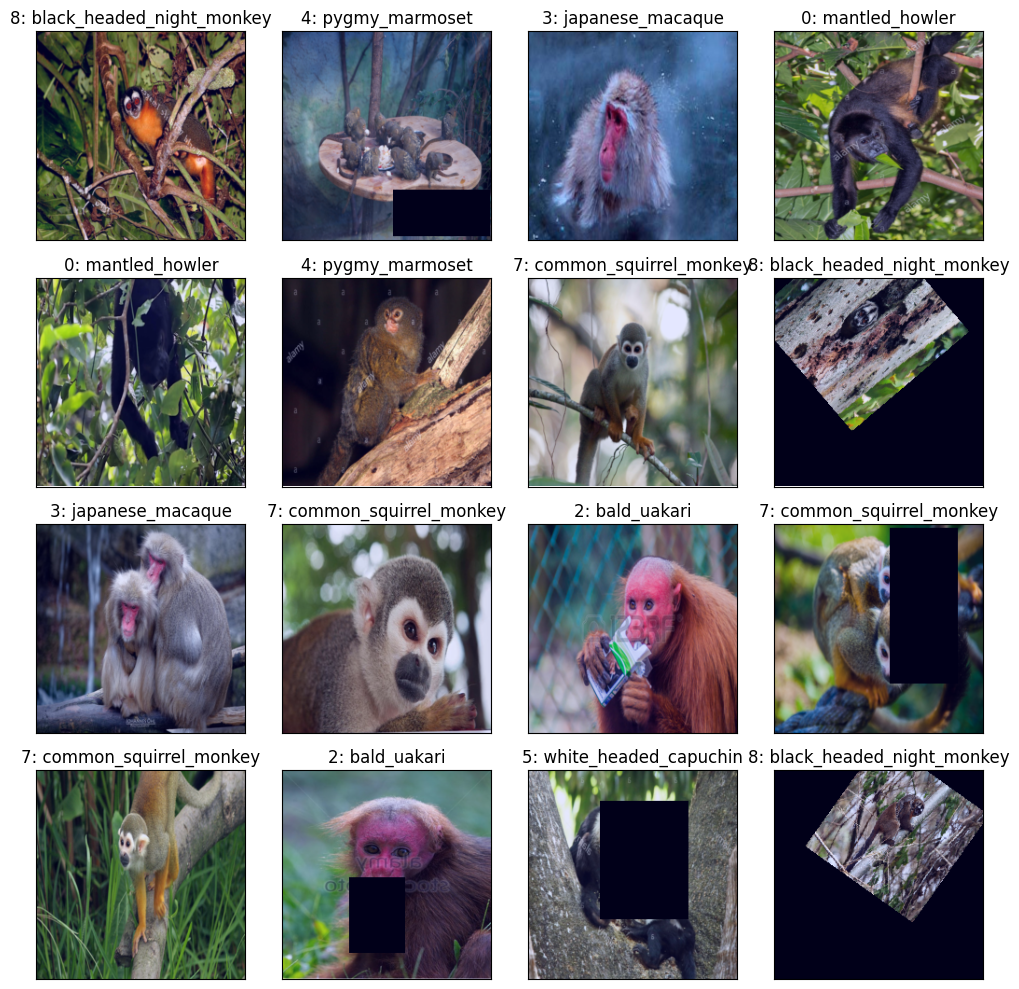

In [42]:
def visualize_images(trainloader, number_of_images=16):
    fig = plt.figure(figsize=(10,10))

    images, labels = next(iter(train_loader))

    num_rows = 4
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])
        
        image = torch.permute(image, (1,2,0))

        image = (image - image.min())/ (image.max() - image.min())
       
        ax.imshow(image)

        ax.set_title(f"{label.item()}: {class_mapping[label.item()]}")

    fig.tight_layout()

    plt.show()
visualize_images(train_loader)

#### CNN Model Implementation

In [52]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self._model = nn.Sequential(
            #-------Convolution Layer-------
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=5),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            #--------------
            nn.LazyConv2d(out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.LazyConv2d(out_channels=128, kernel_size=3),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            #----------------
            Conv2dNormActivation(in_channels=128, out_channels=256, kernel_size=3),
            Conv2dNormActivation(in_channels=256, out_channels=256, kernel_size=3),
            nn.MaxPool2d(kernel_size=2),

            Conv2dNormActivation(in_channels=256, out_channels=512, kernel_size=3),
            nn.MaxPool2d(kernel_size=2),
            
            #-------Feedforward---------
            nn.AdaptiveAvgPool2d(output_size=(3,3)),

            #-------Flatten------------
            nn.Flatten(),

            #------Classification------
            nn.Linear(in_features=512*3*3, out_features=256),
            nn.Linear(in_features=256, out_features=10)   
        )
        
    def forward(self, x):
        return self._model(x)

In [53]:
model = Model()

optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate)

logdir = "runs/80epoch-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,3,224,224)

print(summary(model, dummy_input, row_settings=["var_names"], device='cpu'))

Layer (type (var_name))                  Output Shape              Param #
Model (Model)                            [1, 10]                   --
├─Sequential (_model)                    [1, 10]                   --
│    └─Conv2d (0)                        [1, 32, 220, 220]         2,432
│    └─BatchNorm2d (1)                   [1, 32, 220, 220]         64
│    └─ReLU (2)                          [1, 32, 220, 220]         --
│    └─Conv2d (3)                        [1, 32, 218, 218]         9,248
│    └─BatchNorm2d (4)                   [1, 32, 218, 218]         64
│    └─ReLU (5)                          [1, 32, 218, 218]         --
│    └─MaxPool2d (6)                     [1, 32, 109, 109]         --
│    └─Conv2d (7)                        [1, 64, 107, 107]         18,496
│    └─BatchNorm2d (8)                   [1, 64, 107, 107]         128
│    └─ReLU (9)                          [1, 64, 107, 107]         --
│    └─Conv2d (10)                       [1, 128, 105, 105]        73,856


#### Model Training and Evaluation

In [54]:
def train(model, trainloader, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)

        loss = F.cross_entropy(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += labels.size(0)

        correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(trainloader)

    accuracy = 100 * correct_prediction/ total_samples

    return avg_loss, accuracy

In [55]:
def validation(model, val_loader, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Training"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            loss = F.cross_entropy(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [59]:
def main(model, trainloader, val_loader, epochs =5, DEVICE='cpu'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(train_config.epochs):
        train_loss, train_accuracy = train(model,train_loader, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accracy:
            best_val_accracy = val_accuracy
            best_weights = model.state.dict()
            print("Saving the model... ")
            torch.save(best_weightss, "best.pt")
            
        
    plt.figure(figsize=[12,5])

    plt.subplot(1,2,1)
    plt.plot(range(0,len(train_losses)), train_losses, label="Train Loss", marker='o')
    plt.plot(range(0,len(train_losses)), val_losses, label="Validation Loss", marker='*')

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")

    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(range(0,len(train_accuracies)), train_accuracies, label="Train Accuracy", marker='o')
    plt.plot(range(0,len(val_accuracies)), val_accuracies, label="Validation Accuracy", marker='*')

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")

    plt.legend()

Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [03:15<00:00,  5.58s/it]


Epoch 1 - Train loss: 1.8852948427200318 Train accuracy: 32.087511394712855 %%% Val loss: 1.8888660603099399 Val accuracy: 34.19117647058823


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [04:47<00:00,  8.21s/it]


Epoch 2 - Train loss: 1.4335063185010637 Train accuracy: 50.501367365542386 %%% Val loss: 1.3142969674534268 Val accuracy: 51.470588235294116


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [04:26<00:00,  7.61s/it]


Epoch 3 - Train loss: 1.2526447943278722 Train accuracy: 56.60893345487694 %%% Val loss: 1.1865068044927385 Val accuracy: 60.661764705882355


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [04:54<00:00,  8.41s/it]


Epoch 4 - Train loss: 1.145139823641096 Train accuracy: 60.072926162260714 %%% Val loss: 1.1438529988129933 Val accuracy: 60.661764705882355


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35/35 [04:52<00:00,  8.36s/it]


Epoch 5 - Train loss: 1.0309655683381216 Train accuracy: 64.08386508659981 %%% Val loss: 1.0623563395606146 Val accuracy: 62.13235294117647


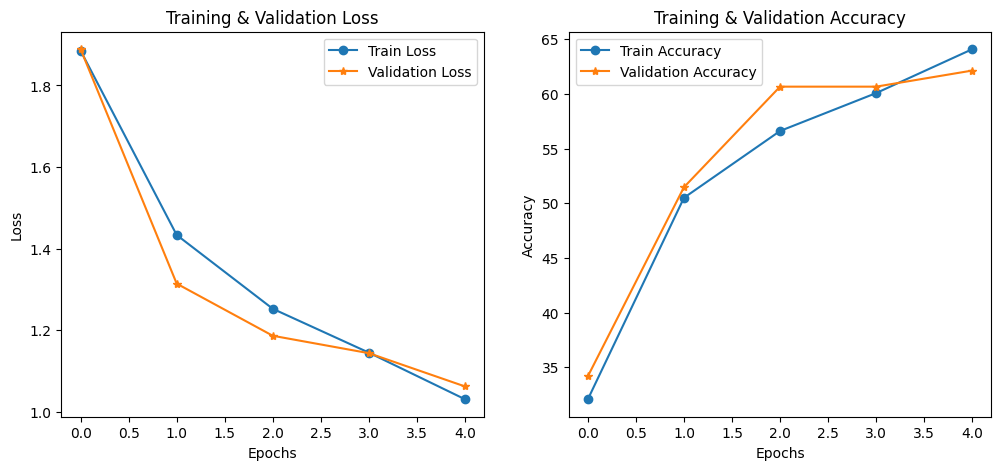

In [60]:
main(model, train_loader, val_loader, 5, 'cpu')

#### Saving and Loading Best Model Weights

In [61]:
# Load the best model weights
model.load_state_dict(torch.load("best.pt"))
model.eval()

FileNotFoundError: [Errno 2] No such file or directory: 'best.pt'

In [62]:
def prediction(model, val_loader):

    model.eval()
    model.to(DEVICE)

    all_images, all_labels = [], []
    all_pred_indices, all_pred_probs = [], []

    for images, labels in val_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.inference_mode():
             outputs = model(images)

        prob = F.softmax(outputs,dim=1)
        pred_indices = prob.data.max(dim=1)[1]
        pred_probs = prob.data.max(dim=1)[0]

        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_pred_indices.append(pred_indices.cpu())
        all_pred_probs.append(pred_probs.cpu())


    return (torch.cat(all_images).numpy(),
            torch.cat(all_labels).numpy(),
            torch.cat(all_pred_indices).numpy(),
            torch.cat(all_pred_probs).numpy())


In [63]:
def denormalize(image):
    mean_ar = np.array(mean)
    std_ar = np.array(std)
    image = image * std_ar + mean_ar
    return np.clip(image, 0,1)

In [64]:
def visualise_predictions(sample_images,sample_gt_labels, pred_indices, pred_probs, num_images =5):

    fig = plt.figure(figsize = (20,5))

    for i in range(num_images):
        idx = random.randint(0, len(sample_images) -1)
        image = sample_images[idx].transpose(1,2,0) #(C,H,W) --> (H,W,C)
        label = sample_gt_labels[idx]
        pred_idx = pred_indices[idx]
        pred_prob = pred_probs[idx]

        image = denormalize(image)

        ax = fig.add_subplot(1, num_images, i+1)
        ax.imshow(image)
        ax.set_title(f"GT: {class_mapping[label]}\nPred: {class_mapping[pred_idx]} ({pred_prob:.2f})")
        ax.axis('off')

    plt.show()

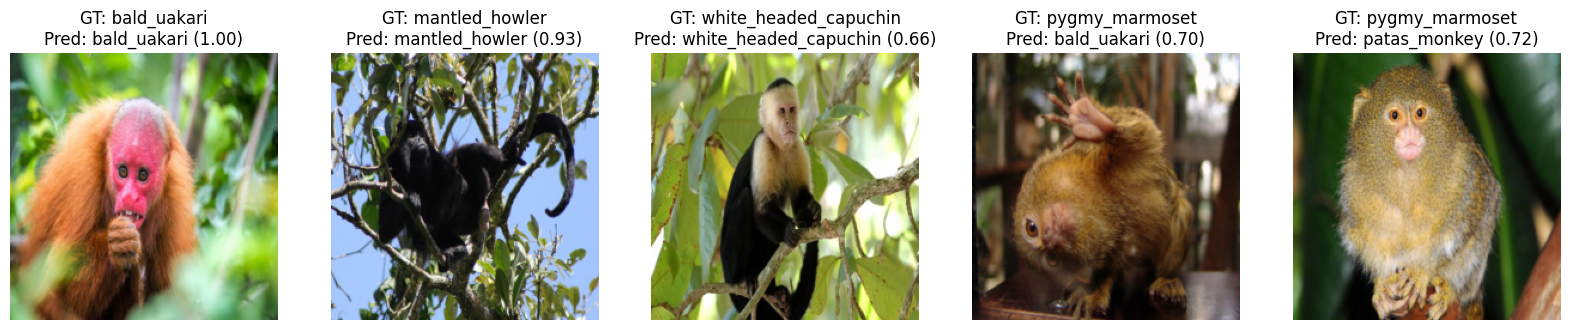

In [65]:
val_images, val_gt_labels, pred_indices, pred_probs = prediction(model, val_loader)

visualise_predictions(val_images, val_gt_labels, pred_indices, pred_probs, num_images = 5)

#### Confusion Matrix

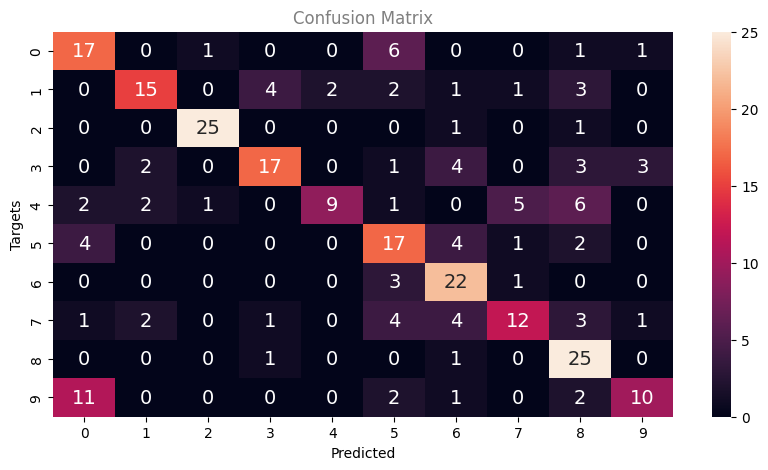

In [66]:
cm = confusion_matrix(y_true=val_gt_labels, y_pred = pred_indices)

plt.figure(figsize= [10,5])
sn.heatmap(cm, annot=True, fmt='d', annot_kws={"size":14})
plt.xlabel("Predicted")
plt.ylabel("Targets")
plt.title(f"Confusion Matrix", color="gray")
plt.show()